# AI in Healthcare - Lab Experiment 1

**Name:** Vanshika Jain
**Course:** CSET343 - AI in Healthcare
**Objective:** Read tabular, textual, image and signal data in different formats and explore them.

## 1. Setup
Installing the libraries

In [1]:
!pip install -q pandas scikit-learn wfdb matplotlib seaborn numpy pillow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.9 MB/s eta 0:00:00


## 2. Tabular Data
Using the Cleveland Heart Disease dataset from UCI.

In [2]:
cols = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach",
        "exang","oldpeak","slope","ca","thal","target"]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = pd.read_csv(url, names=cols, na_values="?")

df.shape

(303, 14)

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
# checking for null values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [5]:
# dropping rows with missing values, only a few so should be fine
df = df.dropna()

# target has values 0-4, converting to binary (0 = no disease, 1 = disease)
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)
df["target"].value_counts()

,count
target,
0,160
1,137


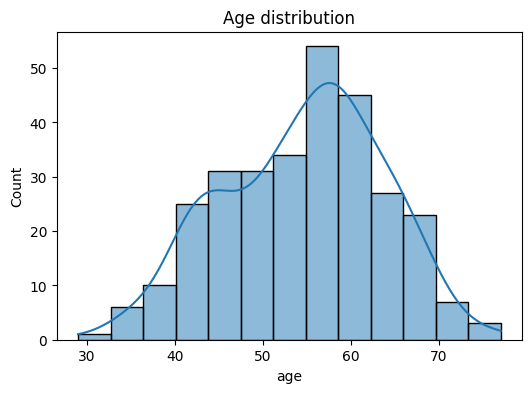

In [6]:
# quick look at the data
plt.figure(figsize=(6,4))
sns.histplot(df["age"], kde=True)
plt.title("Age distribution")
plt.show()

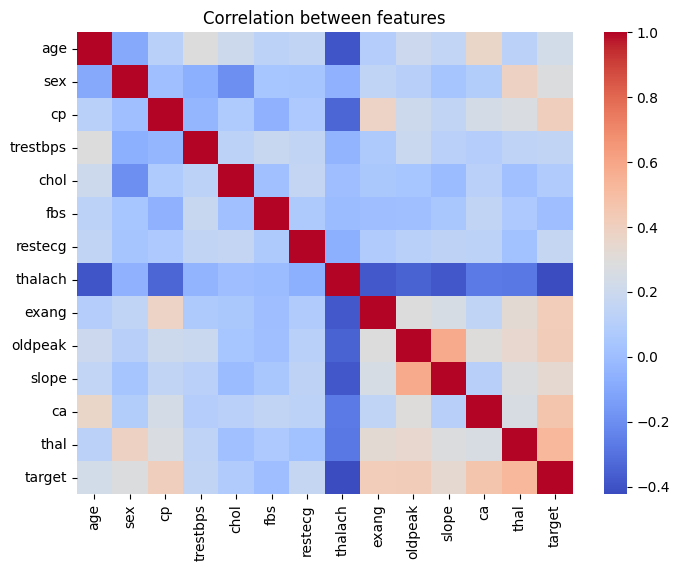

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation between features")
plt.show()

Now training a simple logistic regression model to predict heart disease.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, prob))
print(confusion_matrix(y_test, pred))

Accuracy: 0.8833333333333333
ROC AUC: 0.9467592592592592
[[32  4]
 [ 3 21]]


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 3. Signal Data - ECG (MIT-BIH dataset)

For this part I used the wfdb library to fetch an actual ECG recording from PhysioNet (record 100).

In [9]:
import wfdb

record = wfdb.rdrecord('100', pn_dir='mitdb')
ann = wfdb.rdann('100', 'atr', pn_dir='mitdb')

print(record.p_signal.shape)
print("sampling freq:", record.fs)
print("no. of beats:", len(ann.sample))

(650000, 2)
sampling freq: 360
no. of beats: 2274


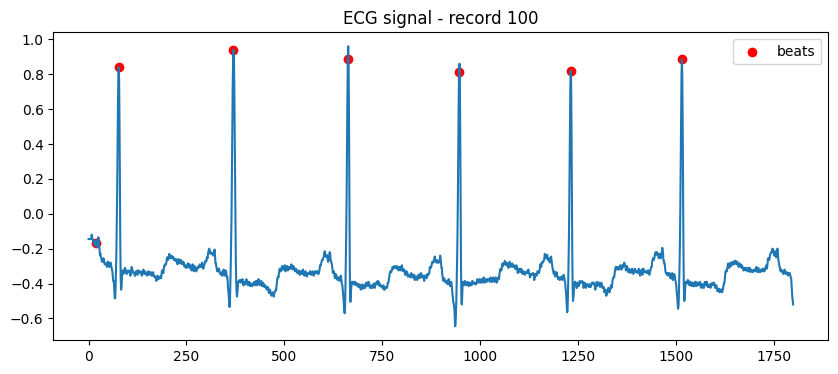

In [10]:
# plotting first 5 sec of signal with the annotated beats
fs = record.fs
sig = record.p_signal[:fs*5, 0]
beats = ann.sample[ann.sample < fs*5]

plt.figure(figsize=(10,4))
plt.plot(sig)
plt.scatter(beats, sig[beats], color="red", label="beats")
plt.title("ECG signal - record 100")
plt.legend()
plt.show()

In [11]:
# rough heart rate from RR intervals
rr = np.diff(ann.sample) / fs
print("avg RR interval:", rr.mean())
print("approx heart rate (bpm):", 60/rr.mean())

avg RR interval: 0.7943161265092633
approx heart rate (bpm): 75.536676138855


In [12]:
note = """
Patient presents with intermittent chest pain radiating to the left arm,
associated with shortness of breath and mild sweating. Pain worsens with
exertion and improves with rest. No prior history of cardiac events.
Blood pressure elevated at time of visit. Recommend ECG and cardiac enzyme panel.
"""

import re
from collections import Counter
tokens = re.findall(r"[a-zA-Z]+", note.lower())
stop_words = {"with","to","the","and","at","of","no","prior","time","visit"}
clean_tokens = [t for t in tokens if t not in stop_words]
freq = Counter(clean_tokens)
freq.most_common(10)

[('pain', 2),
 ('cardiac', 2),
 ('patient', 1),
 ('presents', 1),
 ('intermittent', 1),
 ('chest', 1),
 ('radiating', 1),
 ('left', 1),
 ('arm', 1),
 ('associated', 1)]

/tmp/ipykernel_945/2807972756.py:5: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode="L")


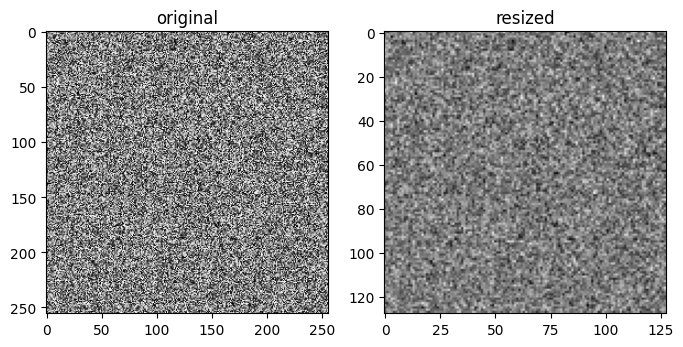

In [13]:
from PIL import Image

np.random.seed(1)
arr = (np.random.rand(256,256)*255).astype(np.uint8)
img = Image.fromarray(arr, mode="L")

resized = img.resize((128,128))

fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].imshow(img, cmap="gray")
ax[0].set_title("original")
ax[1].imshow(resized, cmap="gray")
ax[1].set_title("resized")
plt.show()

## 6. Integration Discussion

The tabular model gives a heart disease risk based on patient stats, but it could be made better by adding features from the ECG signal, like heart rate variability from the RR intervals in part 3. Similarly the clinical note in part 4 has symptom words like "chest" and "pain" which could be turned into extra features and added to the same model. If all of this is linked to the same patient ID, it becomes one combined dataset that a model can be trained on instead of using each modality separately.